In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class PINN(nn.Module):

    def __init__(self,layers):

        super().__init__()

        self.activation = nn.Tanh()
        self.layers = nn.ModuleList()

        for i in range(len(layers)-1):
            self.layers.append(nn.Linear(layers[i],layers[i+1]))

    def forward(self,x):

        for i in range(len(self.layers)-1):
            x = self.activation(self.layers[i](x))

        x = self.layers[-1](x)

        return x

layers = [2,64,64,64,1]
model = PINN(layers)

Random Sampling

In [3]:
def sample_interior(n):

    x = torch.rand(n,1)
    y = torch.rand(n,1)

    pts = torch.cat([x,y],dim=1)

    pts.requires_grad = True

    return pts

In [4]:
def sample_boundary(n):

    x = torch.rand(n,1)
    y = torch.rand(n,1)

    top = torch.cat([x, torch.ones_like(x)],1)
    bottom = torch.cat([x, torch.zeros_like(x)],1)

    left = torch.cat([torch.zeros_like(y),y],1)
    right = torch.cat([torch.ones_like(y),y],1)

    pts = torch.cat([top,bottom,left,right],0)

    return pts

In [5]:
def pde_residual(model,pts):

    u = model(pts)

    grads = torch.autograd.grad(
        u, pts,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = grads[:,0:1]
    u_y = grads[:,1:2]

    u_xx = torch.autograd.grad(
        u_x, pts,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0][:,0:1]

    u_yy = torch.autograd.grad(
        u_y, pts,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0][:,1:2]

    forcing = -2*np.pi**2*torch.sin(np.pi*pts[:,0:1])*torch.sin(np.pi*pts[:,1:2])

    residual = u_xx + u_yy - forcing

    return residual

In [6]:
def physics_loss(model,pts):
    r = pde_residual(model,pts)
    return torch.mean(r**2)

def boundary_loss(model,pts):
  pred = model(pts)
  return torch.mean(pred**2)

In [7]:
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

epochs = 8000

loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    interior = sample_interior(2000)
    boundary = sample_boundary(500)

    p_loss = physics_loss(model,interior)
    b_loss = boundary_loss(model,boundary)

    loss = p_loss + b_loss

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if epoch%500==0:
        print(epoch,loss.item())

0 99.88848114013672
500 0.041795551776885986
1000 0.01621490716934204
1500 0.011115089058876038
2000 0.009623300284147263
2500 0.007113470695912838
3000 0.008839305490255356
3500 0.006355263292789459
4000 0.00542076351121068
4500 0.004177193157374859
5000 0.0043273684568703175
5500 0.003253696020692587
6000 0.003418845823034644
6500 0.00252079707570374
7000 0.0021297605708241463
7500 0.010637927800416946


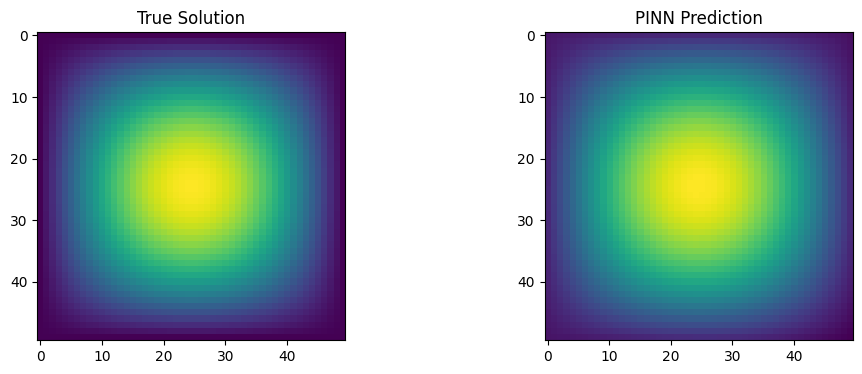

In [8]:
grid = 50

x = torch.linspace(0,1,grid)
y = torch.linspace(0,1,grid)

X,Y = torch.meshgrid(x,y,indexing="ij")

pts = torch.stack([X.flatten(),Y.flatten()],1)

with torch.no_grad():

    pred = model(pts)

pred = pred.reshape(grid,grid)

true = torch.sin(np.pi*X)*torch.sin(np.pi*Y)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(true)
plt.title("True Solution")

plt.subplot(1,2,2)
plt.imshow(pred)
plt.title("PINN Prediction")

plt.show()

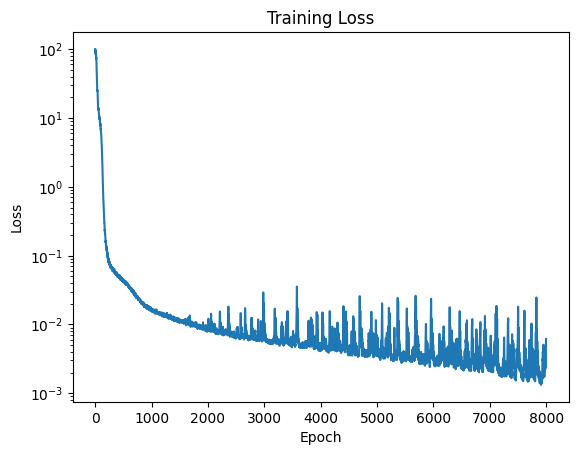

In [10]:
plt.figure()
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()